# 11.4 权重初始化与批量归一化

> **模块十一 · PyTorch深度学习实践** | 第7-8课时
>
> **学习目标：**
> 1. 理解权重初始化的重要性
> 2. 掌握 Xavier 初始化和 He 初始化的原理
> 3. 熟练使用 `nn.init` 方法
> 4. 理解 Batch Normalization 的原理和作用
> 5. 了解 LayerNorm 和 InstanceNorm

---

## 1. 为什么需要权重初始化？

### 1.1 问题：梯度消失与梯度爆炸

假设一个 $L$ 层的全连接网络，每层使用相同的权重初始化方差 $\text{Var}(W)$：

**前向传播**中，信号的方差在逐层传播后会变化：
$$\text{Var}(h_L) = \text{Var}(x) \cdot (n \cdot \text{Var}(W))^L$$

其中 $n$ 是每层的输入维度。

- 如果 $n \cdot \text{Var}(W) > 1$：方差**指数增长** → **梯度爆炸**
- 如果 $n \cdot \text{Var}(W) < 1$：方差**指数衰减** → **梯度消失**

**理想目标：** 让信号方差在每一层保持不变，即 $n \cdot \text{Var}(W) = 1$。

### 1.2 默认初始化的问题

PyTorch 默认使用均匀分布初始化 $U(-\sqrt{k}, \sqrt{k})$，其中 $k = \frac{1}{\text{in\_features}}$。
这对某些激活函数来说并不最优。

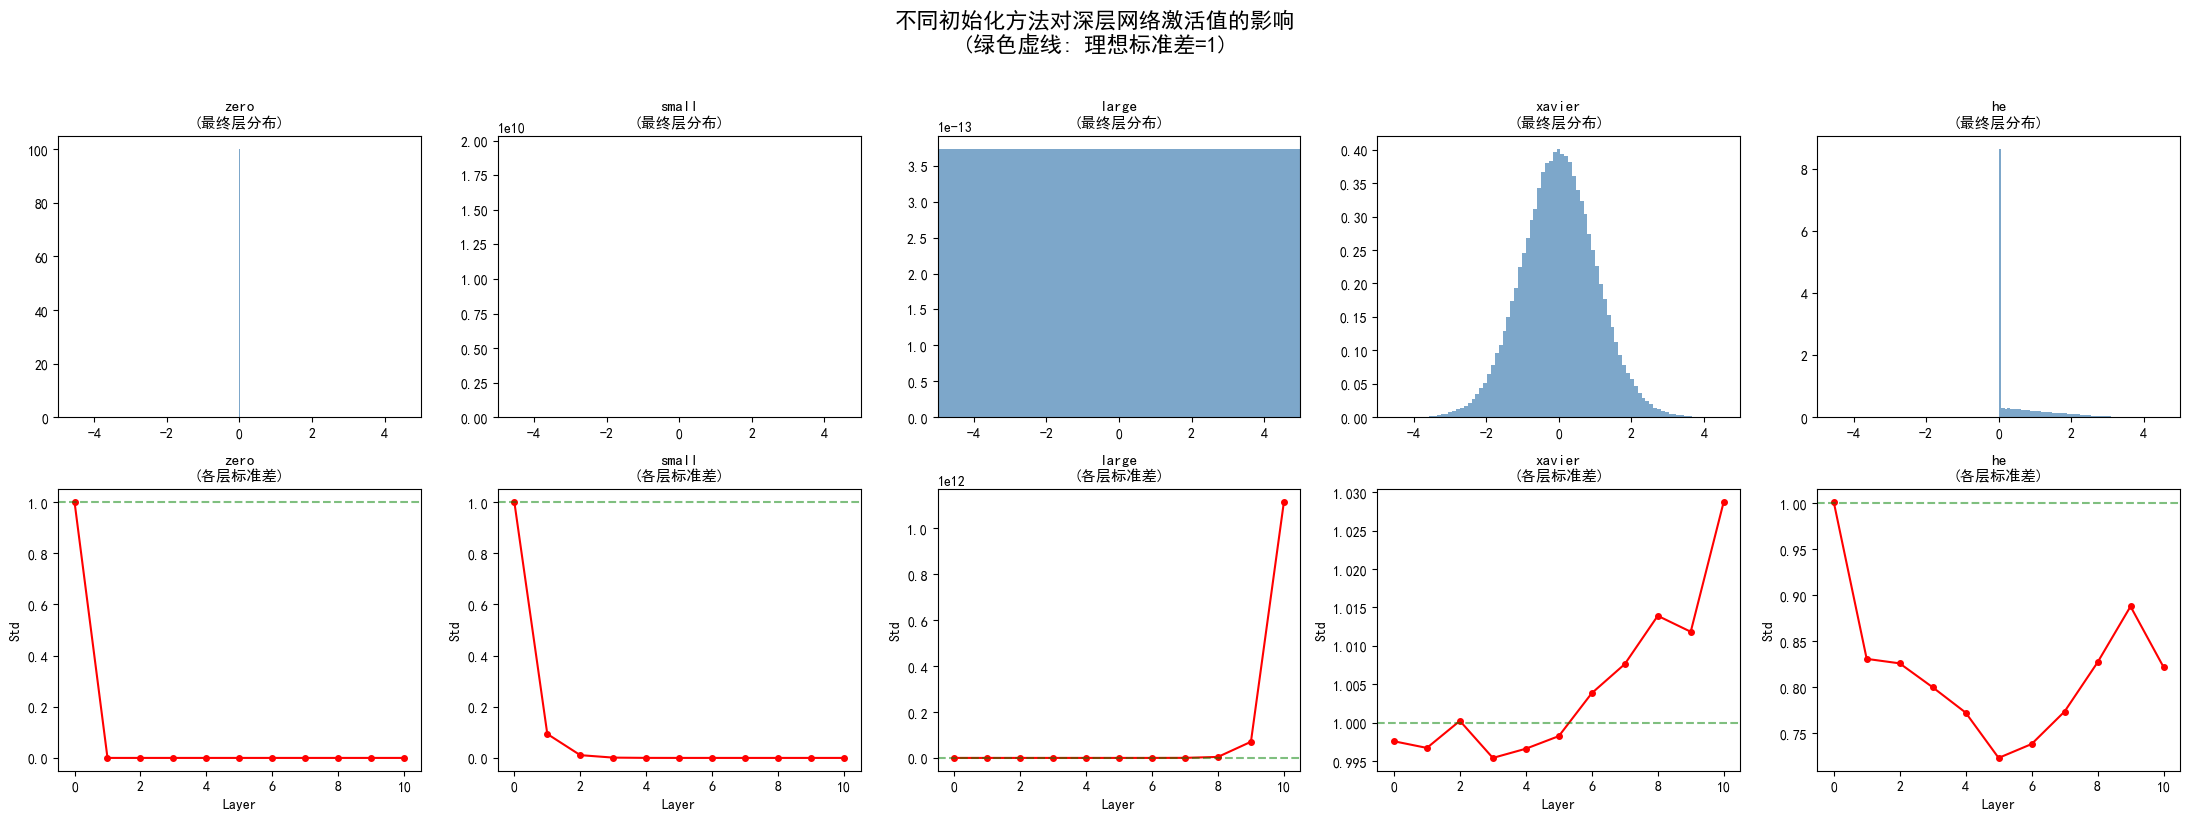

In [22]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']   # 使用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False     # 正常显示负号

# ========== 演示: 不同初始化对激活值的影响 ==========
def show_activation_distribution(init_type, layers=10, n_features=256, n_samples=1000):
    """观察不同初始化下，激活值在多层传播后的分布变化"""
    x = torch.randn(n_samples, n_features)
    activations = [x]  # 保存每层激活值
    
    for i in range(layers):
        layer = nn.Linear(n_features, n_features, bias=False)
        
        if init_type == 'zero':
            nn.init.zeros_(layer.weight)
        elif init_type == 'small':
            nn.init.normal_(layer.weight, mean=0, std=0.01)
        elif init_type == 'large':
            nn.init.normal_(layer.weight, mean=0, std=1.0)
        elif init_type == 'xavier':
            nn.init.xavier_uniform_(layer.weight)
        elif init_type == 'he':
            nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
        
        with torch.no_grad():
            x = layer(x)
            if init_type in ['he', 'small', 'zero']:
                x = torch.relu(x)  # ReLU 激活
            activations.append(x)
    
    return activations


init_types = ['zero', 'small', 'large', 'xavier', 'he']
fig, axes = plt.subplots(2, 5, figsize=(22, 8))

for col, init_type in enumerate(init_types):
    activations = show_activation_distribution(init_type)
    
    # 上行: 最后一层的激活值分布
    final_act = activations[-1].detach().numpy().flatten()
    axes[0, col].hist(final_act, bins=100, density=True, alpha=0.7, color='steelblue')
    axes[0, col].set_title(f'{init_type}\n(最终层分布)', fontsize=11)
    axes[0, col].set_xlim(-5, 5)
    
    # 下行: 各层激活值的标准差
    stds = [a.std().item() for a in activations]
    axes[1, col].plot(range(len(stds)), stds, 'ro-', markersize=4)
    axes[1, col].axhline(y=1.0, color='g', linestyle='--', alpha=0.5)
    axes[1, col].set_title(f'{init_type}\n(各层标准差)', fontsize=11)
    axes[1, col].set_xlabel('Layer')
    axes[1, col].set_ylabel('Std')
    
plt.suptitle('不同初始化方法对深层网络激活值的影响\n(绿色虚线: 理想标准差=1)', 
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

---
## 2. Xavier 初始化 (Glorot 初始化)

### 2.1 理论推导

Xavier 初始化由 Glorot & Bengio (2010) 提出，核心思想是让**前向传播和反向传播**中的信号方差都保持稳定。

对于均匀分布：

$$W \sim U\left(-\sqrt{\frac{6}{n_{in} + n_{out}}}, \sqrt{\frac{6}{n_{in} + n_{out}}}\right)$$

对于正态分布：

$$W \sim \mathcal{N}\left(0, \sqrt{\frac{2}{n_{in} + n_{out}}}\right)$$

**适用场景：** 使用 **tanh** 或 **sigmoid** 激活函数的网络。

**推导直觉：** 兼顾前向（$n_{in}$）和反向（$n_{out}$）两个方向，取折中值。

### 2.2 He 初始化 (Kaiming 初始化)

### 2.2 理论推导

He 初始化由 He et al. (2015) 提出，专门针对 **ReLU** 激活函数。

由于 ReLU 将一半的神经元置零（期望方差减半），需要额外补偿：

$$W \sim \mathcal{N}\left(0, \sqrt{\frac{2}{n_{in}}}\right)$$

对于 LeakyReLU（斜率 $a$）：

$$W \sim \mathcal{N}\left(0, \sqrt{\frac{2}{(1 + a^2) \cdot n_{in}}}\right)$$

**适用场景：** 使用 **ReLU** / **LeakyReLU** 激活函数的网络。

**与 Xavier 的区别：**

| 方法 | 分母 | 适用激活 |
|------|------|----------|
| Xavier | $n_{in} + n_{out}$ | tanh, sigmoid |
| He | $n_{in}$ | ReLU, LeakyReLU |

He 初始化的方差是 Xavier 的约 2 倍，补偿 ReLU 造成的方差损失。

---
## 3. `nn.init` 初始化方法

PyTorch 的 `torch.nn.init` 模块提供了丰富的初始化方法：

In [23]:
# ========== nn.init 常用方法 ==========

layer = nn.Linear(256, 128)
print(f"线性层权重形状: {layer.weight.shape}")  # (128, 256)

# 1. Xavier 均匀分布
nn.init.xavier_uniform_(layer.weight)
print(f"\nXavier Uniform: std = {layer.weight.std():.4f}")

# 2. Xavier 正态分布
nn.init.xavier_normal_(layer.weight)
print(f"Xavier Normal:  std = {layer.weight.std():.4f}")

# 3. He/Kaiming 均匀分布 (用于 ReLU)
nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')
print(f"He Uniform:     std = {layer.weight.std():.4f}")

# 4. He/Kaiming 正态分布 (用于 ReLU)
nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
print(f"He Normal:      std = {layer.weight.std():.4f}")

# 5. 正态分布
nn.init.normal_(layer.weight, mean=0, std=0.02)
print(f"Normal(0,0.02): std = {layer.weight.std():.4f}")

# 6. 均匀分布
nn.init.uniform_(layer.weight, a=-0.1, b=0.1)
print(f"Uniform:         std = {layer.weight.std():.4f}")

# 7. 常数初始化
nn.init.constant_(layer.weight, val=0.01)
print(f"Constant(0.01):  all = {layer.weight[0,0]:.4f}")

# 8. 单位矩阵初始化 (适合残差连接)
square_layer = nn.Linear(128, 128)
nn.init.eye_(square_layer.weight)
print(f"\nEye init 对角线: {square_layer.weight[0,0]:.4f}, 非对角: {square_layer.weight[0,1]:.4f}")

# 9. 正交初始化 (适合 RNN)
nn.init.orthogonal_(square_layer.weight)
print(f"Orthogonal init: std = {square_layer.weight.std():.4f}")

线性层权重形状: torch.Size([128, 256])

Xavier Uniform: std = 0.0725
Xavier Normal:  std = 0.0723
He Uniform:     std = 0.0883
He Normal:      std = 0.0880
Normal(0,0.02): std = 0.0200
Uniform:         std = 0.0577
Constant(0.01):  all = 0.0100

Eye init 对角线: 1.0000, 非对角: 0.0000
Orthogonal init: std = 0.0884


In [24]:
# ========== 批量初始化整个模型的权重 ==========

def init_weights(m):
    """自定义权重初始化函数"""
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)   # gamma = 1
        nn.init.constant_(m.bias, 0)     # beta = 0


# 应用到模型
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.bn2 = nn.BatchNorm2d(64)
        self.fc = nn.Linear(64 * 24 * 24, 10)
    
    def forward(self, x):
        x = torch.relu(self.bn1(self.conv1(x)))
        x = torch.relu(self.bn2(self.conv2(x)))
        x = x.view(x.size(0), -1)
        return self.fc(x)


model = SimpleCNN()
print("初始化前:")
print(f"  conv1.weight std: {model.conv1.weight.std():.4f}")
print(f"  fc.weight std:     {model.fc.weight.std():.4f}")

# 应用自定义初始化
model.apply(init_weights)
print("\n初始化后:")
print(f"  conv1.weight std: {model.conv1.weight.std():.4f}")
print(f"  fc.weight std:     {model.fc.weight.std():.4f}")
print(f"  bn1.weight:        {model.bn1.weight[:5]} (应该全是1)")
print(f"  bn1.bias:          {model.bn1.bias[:5]} (应该全是0)")

初始化前:
  conv1.weight std: 0.1917
  fc.weight std:     0.0030

初始化后:
  conv1.weight std: 0.4443
  fc.weight std:     0.0074
  bn1.weight:        tensor([1., 1., 1., 1., 1.], grad_fn=<SliceBackward0>) (应该全是1)
  bn1.bias:          tensor([0., 0., 0., 0., 0.], grad_fn=<SliceBackward0>) (应该全是0)


---
## 4. 不同初始化方法的梯度对比实验

通过可视化梯度分布，直观对比不同初始化方法的效果。

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

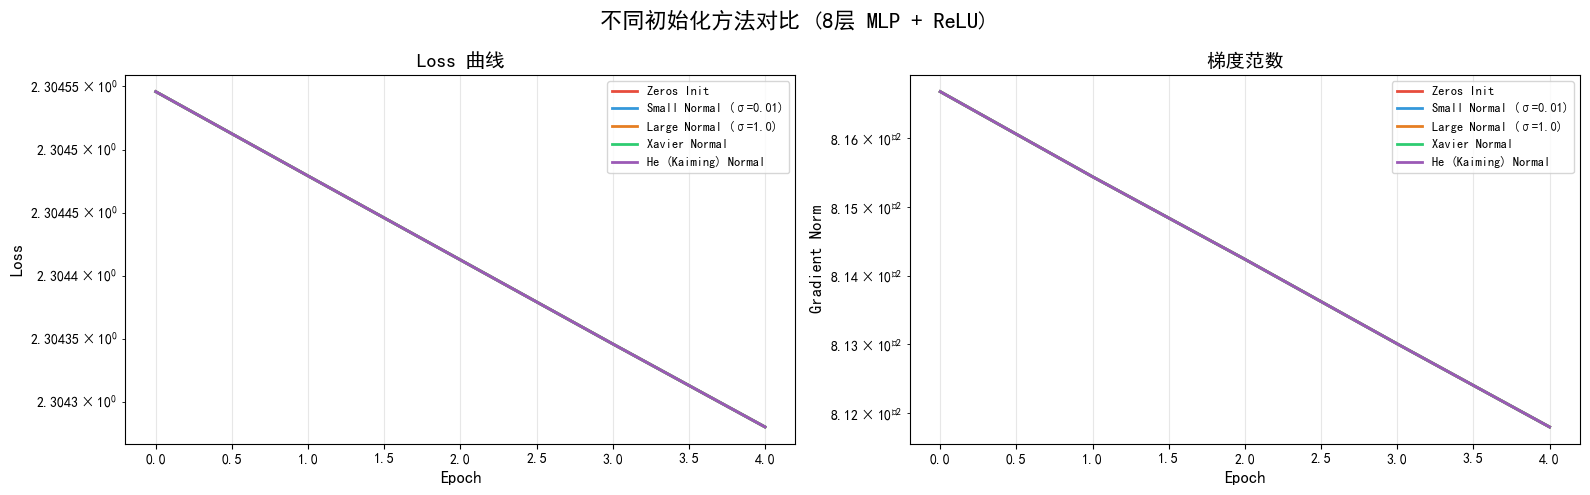

In [25]:
# ========== 梯度分布对比实验 ==========

def train_with_init(init_name, init_func, n_epochs=5, lr=0.01):
    """使用指定初始化方法训练一个深层网络"""
    torch.manual_seed(42)
    
    # 构建深层 MLP (8层)
    layers = []
    for _ in range(8):
        layers.extend([nn.Linear(256, 256), nn.ReLU()])
    layers.append(nn.Linear(256, 10))
    model = nn.Sequential(*layers)
    
    # 应用初始化
    init_func(model)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    
    # 生成随机数据
    X = torch.randn(256, 256)
    y = torch.randint(0, 10, (256,))
    
    losses = []
    grad_norms = []
    
    for epoch in range(n_epochs):
        output = model(X)
        loss = criterion(output, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        
        # 记录梯度范数
        total_norm = 0
        for p in model.parameters():
            if p.grad is not None:
                total_norm += p.grad.norm().item() ** 2
        grad_norms.append(total_norm ** 0.5)
    
    return losses, grad_norms


# ========== 不同初始化方法对比 ==========
def init_zeros(m):
    if isinstance(m, nn.Linear):
        nn.init.zeros_(m.weight)
        nn.init.zeros_(m.bias)

def init_small_normal(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, std=0.01)
        nn.init.zeros_(m.bias)

def init_large_normal(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, std=1.0)
        nn.init.zeros_(m.bias)

def init_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.zeros_(m.bias)

def init_he(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        nn.init.zeros_(m.bias)


configs = {
    'Zeros Init': init_zeros,
    'Small Normal (σ=0.01)': init_small_normal,
    'Large Normal (σ=1.0)': init_large_normal,
    'Xavier Normal': init_xavier,
    'He (Kaiming) Normal': init_he,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = ['#e74c3c', '#3498db', '#e67e22', '#2ecc71', '#9b59b6']

for idx, (name, init_func) in enumerate(configs.items()):
    try:
        losses, grad_norms = train_with_init(name, init_func)
        axes[0].plot(losses, label=name, color=colors[idx], linewidth=2)
        axes[1].plot(grad_norms, label=name, color=colors[idx], linewidth=2)
    except Exception as e:
        print(f"{name}: 训练失败 - {e}")

axes[0].set_title('Loss 曲线', fontsize=14)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_yscale('log')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_title('梯度范数', fontsize=14)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Gradient Norm', fontsize=12)
axes[1].set_yscale('log')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('不同初始化方法对比 (8层 MLP + ReLU)', fontsize=16)
plt.tight_layout()
plt.show()

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


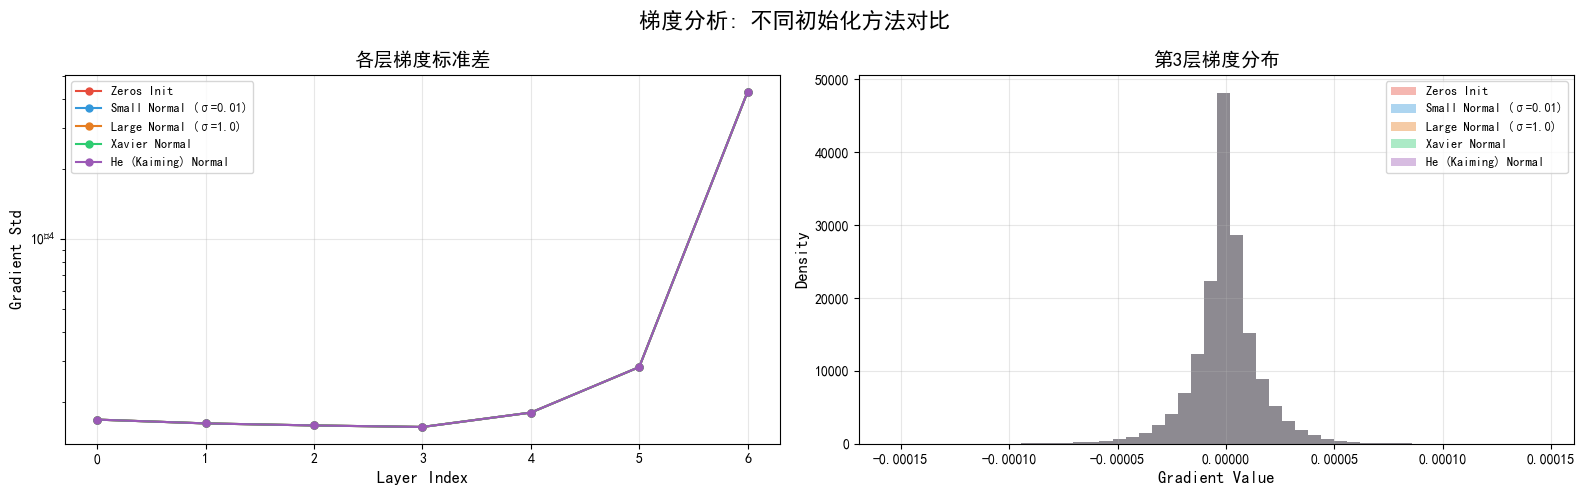

In [26]:
# ========== 梯度分布可视化 ==========

def collect_gradients(init_func):
    """收集各层梯度的分布"""
    torch.manual_seed(42)
    
    layers = []
    for _ in range(6):
        layers.extend([nn.Linear(512, 512), nn.ReLU()])
    layers.append(nn.Linear(512, 10))
    model = nn.Sequential(*layers)
    
    init_func(model)
    
    X = torch.randn(128, 512)
    y = torch.randint(0, 10, (128,))
    
    output = model(X)
    loss = nn.CrossEntropyLoss()(output, y)
    loss.backward()
    
    grad_stds = []
    for name, param in model.named_parameters():
        if param.grad is not None and 'weight' in name:
            grad_stds.append(param.grad.std().item())
    
    return grad_stds


fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 左图: 各层梯度标准差
for idx, (name, init_func) in enumerate(configs.items()):
    try:
        grad_stds = collect_gradients(init_func)
        axes[0].plot(grad_stds, 'o-', label=name, color=colors[idx], markersize=5)
    except Exception:
        pass

axes[0].set_title('各层梯度标准差', fontsize=14)
axes[0].set_xlabel('Layer Index', fontsize=12)
axes[0].set_ylabel('Gradient Std', fontsize=12)
axes[0].set_yscale('log')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# 右图: 梯度直方图对比 (第3层)
for idx, (name, init_func) in enumerate(configs.items()):
    try:
        torch.manual_seed(42)
        layers = []
        for _ in range(6):
            layers.extend([nn.Linear(512, 512), nn.ReLU()])
        layers.append(nn.Linear(512, 10))
        model = nn.Sequential(*layers)
        init_func(model)
        X = torch.randn(128, 512)
        y = torch.randint(0, 10, (128,))
        output = model(X)
        loss = nn.CrossEntropyLoss()(output, y)
        loss.backward()
        
        # 取第3个Linear层的梯度
        grads = list(model.parameters())[4].grad.flatten().numpy()
        grads = grads[np.abs(grads) < 0.1]  # 裁剪极端值
        axes[1].hist(grads, bins=50, density=True, alpha=0.4, color=colors[idx], label=name)
    except Exception:
        pass

axes[1].set_title('第3层梯度分布', fontsize=14)
axes[1].set_xlabel('Gradient Value', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('梯度分析: 不同初始化方法对比', fontsize=16)
plt.tight_layout()
plt.show()

---
## 5. Batch Normalization (批量归一化)

### 5.1 动机：内部协变量偏移 (Internal Covariate Shift)

在深层网络中，由于各层参数在训练中不断更新，**每层输入的分布**会持续变化。这种现象被称为**内部协变量偏移**。

**后果：**
- 上层需要不断适应新的输入分布
- 训练速度慢
- 对初始化敏感

**Batch Normalization 的解决思路：**
将每层输入**标准化为零均值、单位方差**，再通过可学习参数恢复表示能力。

### 5.2 BN 的计算过程

对于一个小批量 $\mathcal{B} = \{x_1, ..., x_m\}$：

1. **计算均值：** $\mu_{\mathcal{B}} = \frac{1}{m}\sum_{i=1}^{m}x_i$
2. **计算方差：** $\sigma_{\mathcal{B}}^2 = \frac{1}{m}\sum_{i=1}^{m}(x_i - \mu_{\mathcal{B}})^2$
3. **标准化：** $\hat{x}_i = \frac{x_i - \mu_{\mathcal{B}}}{\sqrt{\sigma_{\mathcal{B}}^2 + \epsilon}}$
4. **缩放和平移：** $y_i = \gamma \hat{x}_i + \beta$

其中 $\gamma$（scale）和 $\beta$（shift）是**可学习参数**，$\epsilon$ 是防止除零的小常数（默认 $10^{-5}$）。

### 5.3 训练 vs 推理

| 模式 | 均值和方差来源 |
|------|---------------|
| 训练 (`train()`) | 当前 batch 的统计量 |
| 推理 (`eval()`) | **Running** 统计量（训练期间累积的指数移动平均） |

Running 统计量更新公式：

$$\mu_{\text{running}} = (1 - \text{momentum}) \cdot \mu_{\text{running}} + \text{momentum} \cdot \mu_{\mathcal{B}}$$

默认 momentum = 0.1。

In [27]:
# ========== Batch Normalization 基本用法 ==========
# 1D BN (用于全连接层)
bn1d = nn.BatchNorm1d(num_features=64)
x = torch.randn(32, 64)  # (batch, features)
y = bn1d(x)
print(f"BatchNorm1d: {x.shape} → {y.shape}")
print(f"输入均值: {x.mean(dim=0)[:5]} (不一致)")
print(f"输出均值: {y.mean(dim=0)[:5]} (接近0)")
print(f"输出方差: {y.var(dim=0, unbiased=False)[:5]} (接近1)")

# 2D BN (用于卷积层)
bn2d = nn.BatchNorm2d(num_features=16)
x_conv = torch.randn(8, 16, 28, 28)  # (batch, channels, H, W)
y_conv = bn2d(x_conv)
print(f"\nBatchNorm2d: {x_conv.shape} → {y_conv.shape}")

# 查看 BN 的可学习参数
print(f"\ngamma (weight): {bn1d.weight[:5]} (初始=1)")
print(f"beta  (bias):   {bn1d.bias[:5]} (初始=0)")
print(f"running_mean:   {bn1d.running_mean[:5]}")
print(f"running_var:    {bn1d.running_var[:5]}")

BatchNorm1d: torch.Size([32, 64]) → torch.Size([32, 64])
输入均值: tensor([ 0.0515, -0.1084,  0.1592, -0.0990, -0.1572]) (不一致)
输出均值: tensor([3.7253e-09, 1.4901e-08, 1.4901e-08, 0.0000e+00, 1.4901e-08],
       grad_fn=<SliceBackward0>) (接近0)
输出方差: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<SliceBackward0>) (接近1)

BatchNorm2d: torch.Size([8, 16, 28, 28]) → torch.Size([8, 16, 28, 28])

gamma (weight): tensor([1., 1., 1., 1., 1.], grad_fn=<SliceBackward0>) (初始=1)
beta  (bias):   tensor([0., 0., 0., 0., 0.], grad_fn=<SliceBackward0>) (初始=0)
running_mean:   tensor([ 0.0052, -0.0108,  0.0159, -0.0099, -0.0157])
running_var:    tensor([1.0041, 1.0120, 0.9986, 0.9964, 0.9651])


In [28]:
# ========== 训练 vs 推理行为对比 ==========

bn = nn.BatchNorm1d(4)

# 训练模式: 使用当前 batch 的统计量
bn.train()
x_train = torch.randn(32, 4) * 5 + 3  # 均值3, 标准差5
y_train = bn(x_train)
print("训练模式:")
print(f"  输入均值: {x_train.mean(dim=0)}")
print(f"  输出均值: {y_train.mean(dim=0)} (被标准化到接近0)")
print(f"  输出方差: {y_train.var(dim=0, unbiased=False)} (被标准化到接近1)")

# 推理模式: 使用 running 统计量
bn.eval()
x_test = torch.randn(32, 4) * 5 + 3
y_test = bn(x_test)
print(f"\n推理模式:")
print(f"  输入均值: {x_test.mean(dim=0)}")
print(f"  输出均值: {y_test.mean(dim=0)} (基于running stats)")
print(f"  输出方差: {y_test.var(dim=0, unbiased=False)}")

# 查看累积的 running statistics
print(f"\nRunning mean (训练后): {bn.running_mean}")
print(f"Running var (训练后):  {bn.running_var}")

训练模式:
  输入均值: tensor([4.2264, 2.8648, 3.1394, 3.5820])
  输出均值: tensor([-1.0803e-07, -5.2154e-08,  0.0000e+00,  2.9802e-08],
       grad_fn=<MeanBackward1>) (被标准化到接近0)
  输出方差: tensor([1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<VarBackward0>) (被标准化到接近1)

推理模式:
  输入均值: tensor([2.9155, 3.2730, 2.5417, 2.6925])
  输出均值: tensor([1.6164, 1.4857, 1.1888, 1.2839], grad_fn=<MeanBackward1>) (基于running stats)
  输出方差: tensor([11.1102,  3.4888,  5.1515,  8.4936], grad_fn=<VarBackward0>)

Running mean (训练后): tensor([0.4226, 0.2865, 0.3139, 0.3582])
Running var (训练后):  tensor([2.3786, 4.0410, 3.5116, 3.3058])


### 5.4 BN 的优点与缺点

**优点：**
- ✅ 加速训练收敛
- ✅ 允许更大的学习率
- ✅ 对初始化不敏感
- ✅ 有轻微的正则化效果（噪声来自 batch 统计量）
- ✅ 减少对 Dropout 的依赖

**缺点：**
- ❌ batch size 太小时统计量不稳定
- ❌ 训练和推理行为不一致（需切换模式）
- ❌ 不适合序列模型（RNN）—— 不同时间步的 batch size 可能不同
- ❌ 无法用于在线学习（batch_size=1）

---
## 6. BN 效果对比实验

对比有/无 BatchNorm 对训练的影响。

训练中... (这可能需要一些时间)
训练完成!


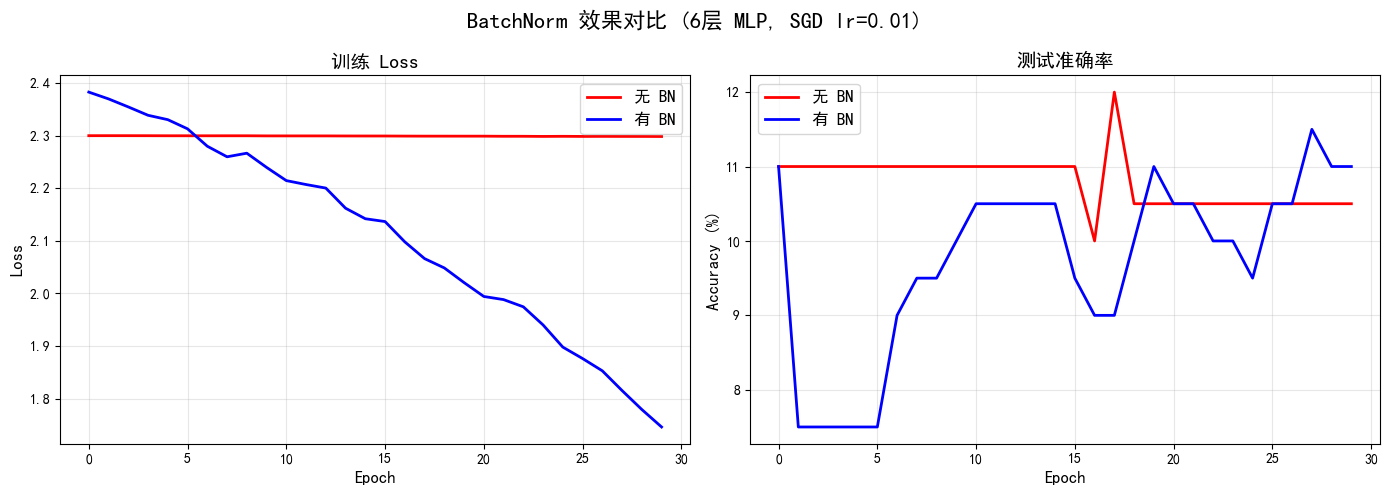

In [29]:
# ========== 有无 BN 的训练对比 ==========

def make_model(use_bn):
    """构建有/无 BN 的模型"""
    layers = []
    in_features = 784
    hidden = 256
    
    for i in range(6):
        layers.append(nn.Linear(in_features if i == 0 else hidden, hidden))
        if use_bn:
            layers.append(nn.BatchNorm1d(hidden))
        layers.append(nn.ReLU())
        if i < 5:  # 最后不加 dropout
            layers.append(nn.Dropout(0.1))
    layers.append(nn.Linear(hidden, 10))
    return nn.Sequential(*layers)


def train_model(use_bn, n_epochs=30, lr=0.01):
    """训练模型并返回训练历史"""
    torch.manual_seed(42)
    model = make_model(use_bn)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    
    # 模拟 MNIST 数据
    X_train = torch.randn(1000, 784)
    y_train = torch.randint(0, 10, (1000,))
    X_test = torch.randn(200, 784)
    y_test = torch.randint(0, 10, (200,))
    
    history = {'train_loss': [], 'test_acc': []}
    
    for epoch in range(n_epochs):
        model.train()
        
        # 前向
        output = model(X_train)
        loss = criterion(output, y_train)
        
        # 反向
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        history['train_loss'].append(loss.item())
        
        # 评估
        model.eval()
        with torch.no_grad():
            test_output = model(X_test)
            pred = test_output.argmax(1)
            acc = (pred == y_test).float().mean().item() * 100
            history['test_acc'].append(acc)
    
    return history


# 训练对比
print("训练中... (这可能需要一些时间)")
history_no_bn = train_model(use_bn=False, n_epochs=30)
history_with_bn = train_model(use_bn=True, n_epochs=30)
print("训练完成!")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_no_bn['train_loss'], 'r-', label='无 BN', linewidth=2)
axes[0].plot(history_with_bn['train_loss'], 'b-', label='有 BN', linewidth=2)
axes[0].set_title('训练 Loss', fontsize=14)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_no_bn['test_acc'], 'r-', label='无 BN', linewidth=2)
axes[1].plot(history_with_bn['test_acc'], 'b-', label='有 BN', linewidth=2)
axes[1].set_title('测试准确率', fontsize=14)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.suptitle('BatchNorm 效果对比 (6层 MLP, SGD lr=0.01)', fontsize=16)
plt.tight_layout()
plt.show()

---
## 7. Layer Normalization 与 Instance Normalization

### 7.1 归一化方法对比

| 方法 | 归一化维度 | 适用场景 |
|------|-----------|----------|
| **BatchNorm** | 同一通道跨 batch | CNN 图像任务 |
| **LayerNorm** | 同一样本所有通道 | RNN / Transformer |
| **InstanceNorm** | 单样本单通道 | 风格迁移 |
| **GroupNorm** | 通道分组内 | 小 batch 任务 |

In [30]:
# ========== 各种归一化方法演示 ==========

# 输入: (batch=2, channels=3, H=4, W=4)
x = torch.randn(2, 3, 4, 4)
print(f"输入形状: {x.shape}")
print(f"原始范围: [{x.min():.2f}, {x.max():.2f}]")

# BatchNorm: 在 (N, H, W) 上对每个通道归一化
bn = nn.BatchNorm2d(3)
y_bn = bn(x)
print(f"\nBatchNorm2d:")
for c in range(3):
    print(f"  通道{c}: mean={y_bn[:,c].mean():.4f}, std={y_bn[:,c].std():.4f}")

# LayerNorm: 在 (C, H, W) 上对每个样本归一化
ln = nn.LayerNorm([3, 4, 4])
y_ln = ln(x)
print(f"\nLayerNorm:")
for n in range(2):
    print(f"  样本{n}: mean={y_ln[n].mean():.4f}, std={y_ln[n].std():.4f}")

# InstanceNorm: 在 (H, W) 上对每个样本每个通道归一化
inorm = nn.InstanceNorm2d(3)
y_in = inorm(x)
print(f"\nInstanceNorm2d:")
for n in range(2):
    for c in range(3):
        print(f"  样本{n} 通道{c}: mean={y_in[n,c].mean():.4f}, std={y_in[n,c].std():.4f}")

# GroupNorm: 将通道分组归一化
gn = nn.GroupNorm(num_groups=3, num_channels=3)  # 每组1个通道
y_gn = gn(x)
print(f"\nGroupNorm(num_groups=3):")
for n in range(2):
    for c in range(3):
        print(f"  样本{n} 通道{c}: mean={y_gn[n,c].mean():.4f}, std={y_gn[n,c].std():.4f}")

输入形状: torch.Size([2, 3, 4, 4])
原始范围: [-2.77, 2.24]

BatchNorm2d:
  通道0: mean=0.0000, std=1.0160
  通道1: mean=-0.0000, std=1.0160
  通道2: mean=0.0000, std=1.0160

LayerNorm:
  样本0: mean=-0.0000, std=1.0106
  样本1: mean=0.0000, std=1.0106

InstanceNorm2d:
  样本0 通道0: mean=-0.0000, std=1.0328
  样本0 通道1: mean=0.0000, std=1.0328
  样本0 通道2: mean=-0.0000, std=1.0328
  样本1 通道0: mean=-0.0000, std=1.0328
  样本1 通道1: mean=0.0000, std=1.0328
  样本1 通道2: mean=0.0000, std=1.0328

GroupNorm(num_groups=3):
  样本0 通道0: mean=-0.0000, std=1.0328
  样本0 通道1: mean=-0.0000, std=1.0328
  样本0 通道2: mean=-0.0000, std=1.0328
  样本1 通道0: mean=-0.0000, std=1.0328
  样本1 通道1: mean=0.0000, std=1.0328
  样本1 通道2: mean=0.0000, std=1.0328


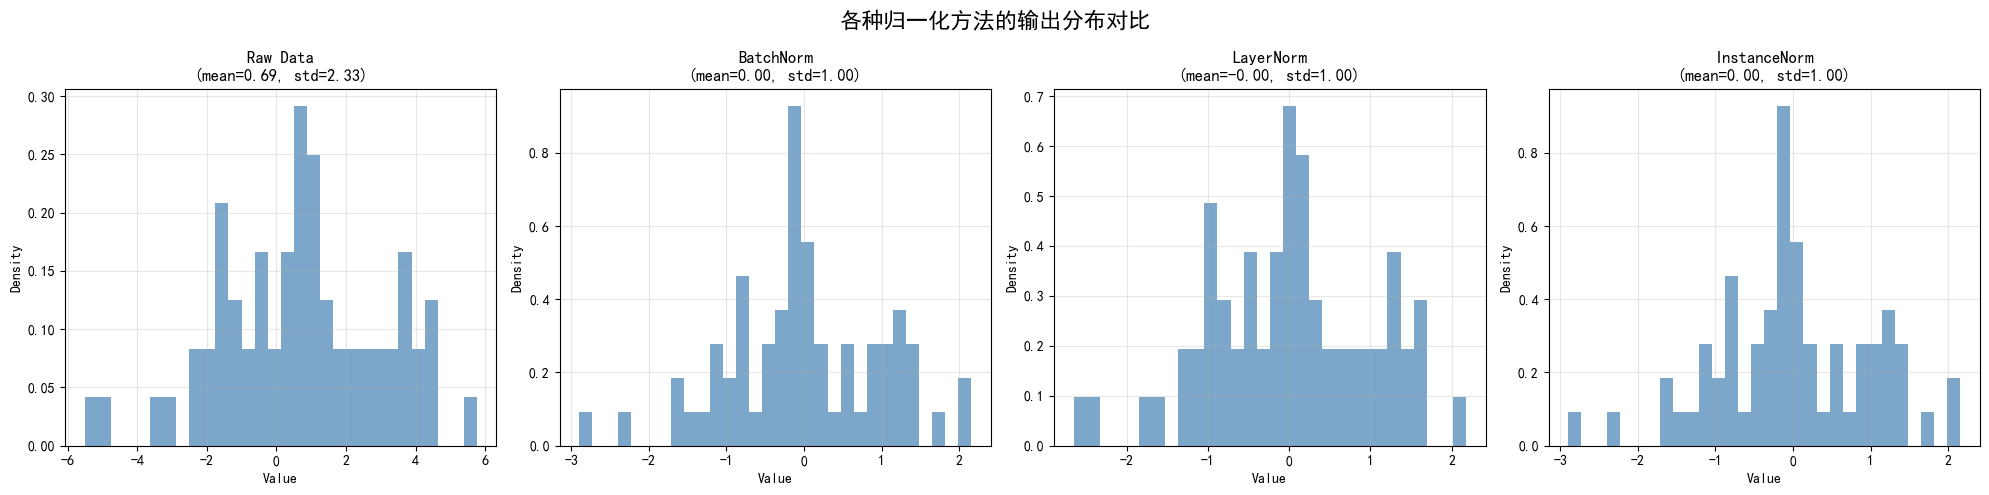

In [31]:
# ========== 直观对比各种归一化 ==========

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

x = torch.randn(1, 4, 4, 4) * 3 + 1  # 偏移较大的数据
norms = {
    'Raw Data': x[0],
    'BatchNorm': nn.BatchNorm2d(4)(x)[0],
    'LayerNorm': nn.LayerNorm([4, 4, 4])(x)[0],
    'InstanceNorm': nn.InstanceNorm2d(4)(x)[0],
}

for ax, (title, data) in zip(axes, norms.items()):
    vals = data.flatten().detach().numpy()
    ax.hist(vals, bins=30, density=True, alpha=0.7, color='steelblue')
    ax.set_title(f'{title}\n(mean={vals.mean():.2f}, std={vals.std():.2f})', fontsize=12)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.grid(True, alpha=0.3)

plt.suptitle('各种归一化方法的输出分布对比', fontsize=16)
plt.tight_layout()
plt.show()

---
## 8. 本节小结

### 权重初始化

| 初始化方法 | 公式（正态分布） | 适用激活 |
|------------|-------------------|----------|
| Xavier/Glorot | $W \sim \mathcal{N}(0, \sqrt{\frac{2}{n_{in}+n_{out}}})$ | tanh, sigmoid |
| He/Kaiming | $W \sim \mathcal{N}(0, \sqrt{\frac{2}{n_{in}}})$ | ReLU |
| Orthogonal | $W^T W = I$ | RNN |

### 批量归一化

1. **标准化**：$\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$
2. **仿射变换**：$y = \gamma \hat{x} + \beta$
3. **训练用 batch 统计量，推理用 running 统计量**
4. `model.train()` / `model.eval()` 切换模式

---

## 📝 练习题

### 练习1: 权重初始化实验

构建一个 10 层的全连接网络（每层 256 个神经元，ReLU 激活），分别使用以下初始化方法：
- 零初始化
- $\mathcal{N}(0, 0.01)$
- $\mathcal{N}(0, 1.0)$
- Xavier Normal
- He Normal

训练 20 个 epoch，绘制各方法的 loss 曲线，并分析哪些方法能有效训练，哪些失败及原因。

### 练习2: BN 位置实验

对比 BN 放在不同位置的效果：
1. `Conv → BN → ReLU`（传统方式）
2. `Conv → ReLU → BN`

使用 MNIST 数据训练一个小 CNN，对比两种放置方式的测试准确率。

### 练习3: GroupNorm 实践

当 batch_size = 2 时，BatchNorm 效果可能不好。尝试用 GroupNorm（num_groups=8, 16, 32）替代 BatchNorm，观察在小 batch 下的训练效果差异。